## Email Spam Detector

In [4]:
import numpy as np
import pandas as pd

In [6]:
df = pd.read_csv('spam.csv', encoding = "latin-1")

In [62]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1296,ham,Sure! I am driving but will reach my destinati...,NaN,NaN,NaN
1720,ham,"Fighting with the world is easy, u either win ...",NaN,NaN,NaN
4311,ham,I keep ten rs in my shelf:) buy two egg.,NaN,NaN,NaN
546,ham,I know but you need to get hotel now. I just g...,NaN,NaN,NaN
1383,ham,Please reserve ticket on saturday eve from che...,NaN,NaN,NaN


In [68]:
df.shape

(5572, 5)

In [69]:
# 1. Data Cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model building
# 5. Evalution
# 6. Improvement
# 7. Website
# 8. Deploy

## 1. Data Cleaning

In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [71]:
df.drop(columns = ["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], inplace = True)

In [72]:
df.sample(3)

,v1,v2
4634,ham,How come i din c Ì_... Yup i cut my hair...
553,ham,Ok. Every night take a warm bath drink a cup o...
4810,ham,E admin building there? I might b slightly ear...


In [76]:
# Renaming of columns

df.rename(columns={'v1' : 'target', 'v2' : 'text'}, inplace = True)

,target,text
103,ham,wow. You're right! I didn't mean to do that. I...
5204,ham,How come she can get it? Should b quite diff t...


In [79]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [80]:
df['target'] = encoder.fit_transform(df['target'])

In [82]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [84]:
# finding NULL values

df.isnull().sum()

target    0
text      0
dtype: int64

In [87]:
# check for duplicated values

df.duplicated().sum()

np.int64(403)

In [90]:
df = df.drop_duplicates(keep = 'first')

In [91]:
df.duplicated().sum()

np.int64(0)

In [92]:
df.shape

(5169, 2)

## 2. EDA

In [94]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

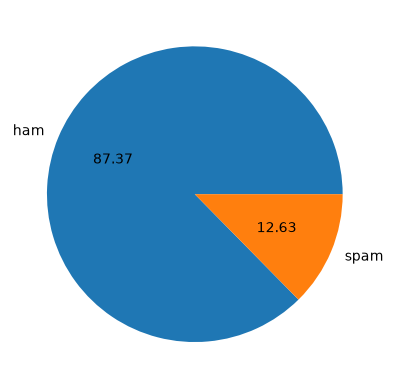

In [102]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels = ['ham', 'spam'], autopct = "%0.2f")
plt.show()

In [103]:
# data is imbalanced



In [105]:
import nltk

In [106]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [108]:
df['num_character'] = df['text'].apply(len)

In [109]:
df.head()

,target,text,num_character
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [118]:
# num of word

df['num_word']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

'Ok lar... Joking wif u oni...'

In [120]:
df['num_sentence'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [123]:
df.sample(5)

,target,text,num_character,num_word,num_sentence
2475,0,Mm i am on the way to railway,29,8,1
4739,0,"I keep seeing weird shit and bein all \woah\"" ...",105,25,1
2516,0,Yes.i'm in office da:),22,7,1
1964,0,Honeybee Said: *I'm d Sweetest in d World* God...,158,42,2
2963,1,"Do you ever notice that when you're driving, a...",135,28,1


In [124]:
df[['num_character', 'num_word', 'num_sentence']].describe()

,num_character,num_word,num_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [125]:
df[df['target']==0][['num_character', 'num_word', 'num_sentence']].describe()

,num_character,num_word,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [127]:
df[df['target']==1][['num_character', 'num_word', 'num_sentence']].describe()

,num_character,num_word,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [130]:
import seaborn as sns

<Axes: xlabel='num_character', ylabel='Count'>

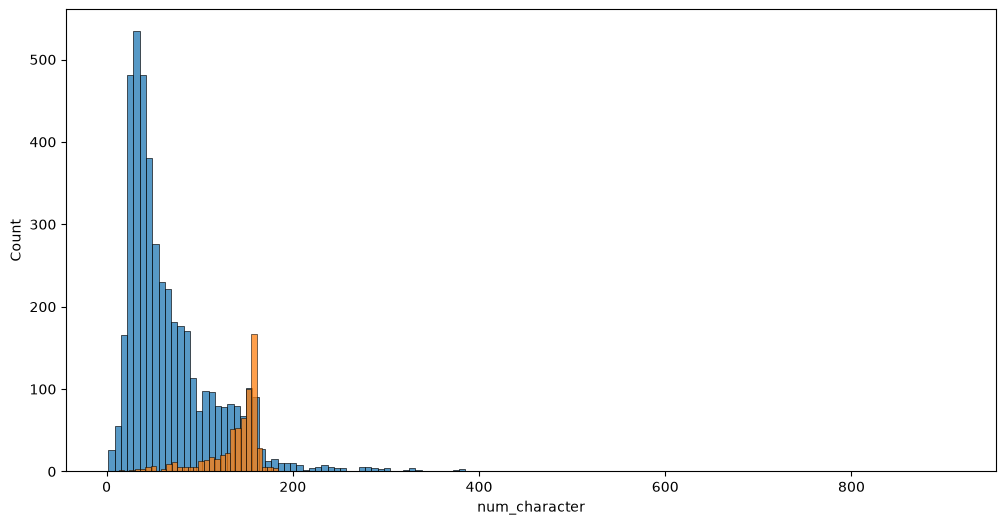

In [134]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_character'])
sns.histplot(df[df['target']==1]['num_character'])

<Axes: xlabel='num_word', ylabel='Count'>

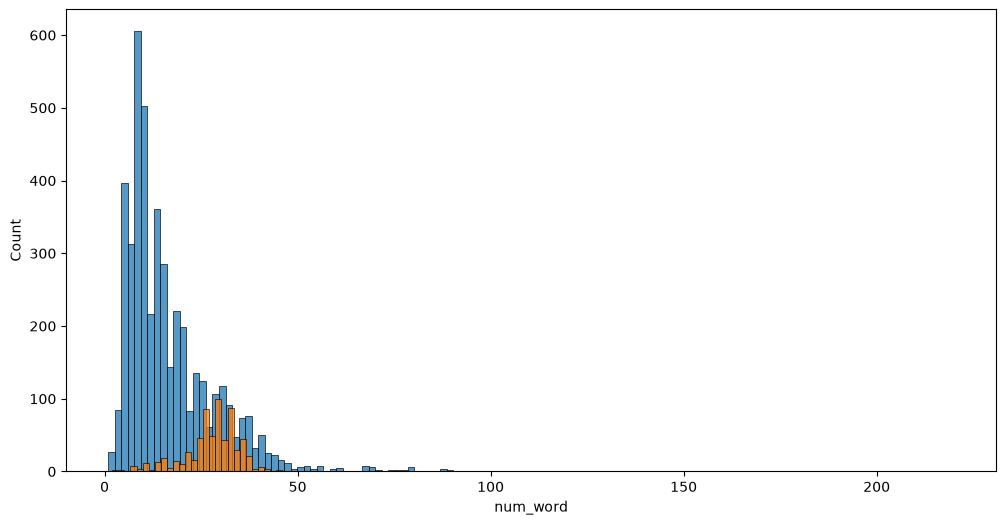

In [136]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_word'])
sns.histplot(df[df['target']==1]['num_word'])

<Axes: xlabel='num_sentence', ylabel='Count'>

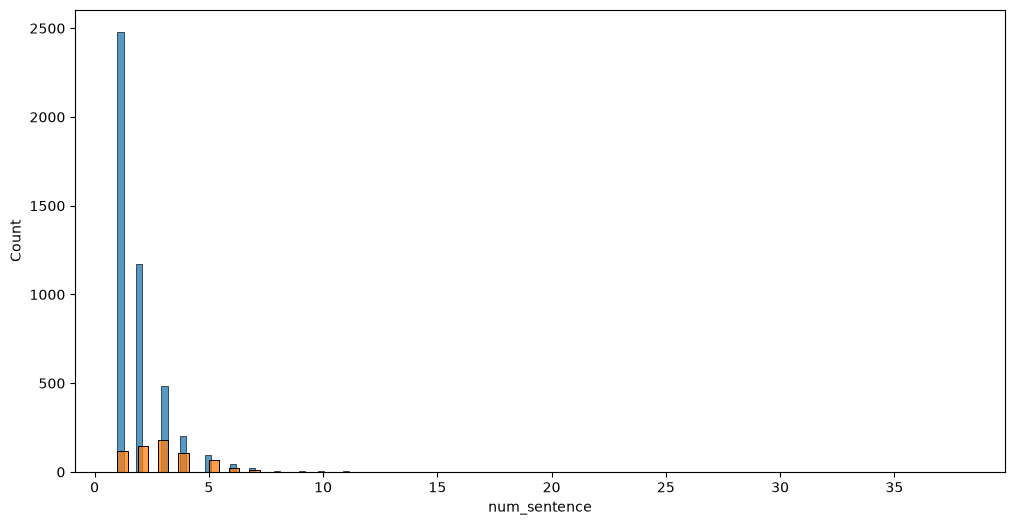

In [137]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_sentence'])
sns.histplot(df[df['target']==1]['num_sentence'])